# 🚦 Day 1 — Data Pipeline + EDA
**ParkSentinel | Gridlock Hackathon 2.0**

Pipeline: Load → Clean → Feature Engineer → EDA → Save Parquet

> Run cells top-to-bottom. `tqdm` progress bars on all heavy operations.


## 1. Environment Setup

In [1]:
import subprocess, sys
pkgs = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "folium", "tqdm", "pyarrow", "scikit-learn",
    "plotly", "h3", "branca", "python-dotenv"
]
print("Installing packages...")
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q","--break-system-packages"],
                   capture_output=True)
print("✅ Done.")


Installing packages...
✅ Done.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium, warnings, ast, re, json, sys
from tqdm import tqdm
from pathlib import Path
from collections import Counter
from dotenv import load_dotenv
import os

load_dotenv()
warnings.filterwarnings("ignore")
tqdm.pandas()

plt.rcParams.update({
    "figure.figsize": (12,5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.titlesize": 13,
    "axes.titleweight": "bold", "figure.dpi": 120,
})
sns.set_palette("husl")

# ── Paths — adjust ROOT to your machine ───────────────────────────────────
ROOT      = Path(r"D:\Coding Stuff\grid2")
RAW_CSV   = ROOT / "data" / "raw" / "jan to may police violation_anonymized.csv"
PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Project root : {ROOT}")
print(f"Dataset path : {RAW_CSV}")
print(f"Exists       : {RAW_CSV.exists()}")


Project root : D:\Coding Stuff\grid2
Dataset path : D:\Coding Stuff\grid2\data\raw\jan to may police violation_anonymized.csv
Exists       : True


## 2. Data Loading & First Look

In [4]:
print("Loading dataset...")
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
print(f"✅ Loaded  →  {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)


Loading dataset...
✅ Loaded  →  298,450 rows × 24 columns


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00


In [5]:
# Null audit
null_df = pd.DataFrame({
    "null_count": df_raw.isnull().sum(),
    "null_pct":   (df_raw.isnull().mean()*100).round(2)
}).sort_values("null_pct", ascending=False)
print("=== NULL REPORT ===")
print(null_df[null_df.null_count > 0].to_string())
print()
print("=== DTYPES ===")
print(df_raw.dtypes.to_string())


=== NULL REPORT ===
                              null_count  null_pct
description                       298450    100.00
action_taken_timestamp            298450    100.00
closed_datetime                   298450    100.00
data_sent_to_scita_timestamp      256289     85.87
validation_timestamp              125254     41.97
validation_status                 125254     41.97
updated_vehicle_type              125254     41.97
updated_vehicle_number            125254     41.97
center_code                        11260      3.77
location                            3041      1.02
junction_name                          5      0.00
police_station                         5      0.00
created_by_id                          5      0.00

=== DTYPES ===
id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
descriptio

## 3. Data Cleaning
Steps: drop duplicates → drop missing coords → bounding-box filter →
parse datetimes → normalise strings → parse JSON arrays


In [6]:
df = df_raw.copy()

# 3a. Duplicates
before = len(df); df.drop_duplicates(inplace=True)
print(f"Dropped {before-len(df):,} exact duplicates")

# 3b. Missing coordinates
before = len(df); df.dropna(subset=["latitude","longitude"], inplace=True)
print(f"Dropped {before-len(df):,} missing lat/lon rows")

# 3c. Bengaluru bounding box
before = len(df)
df = df[df.latitude.between(12.7,13.2) & df.longitude.between(77.4,77.9)]
print(f"Dropped {before-len(df):,} out-of-bounds rows")
print(f"✅ Clean shape: {df.shape}")


Dropped 0 exact duplicates
Dropped 0 missing lat/lon rows
Dropped 168 out-of-bounds rows
✅ Clean shape: (298282, 24)


In [8]:
# 3d. Parse datetimes → IST
IST = "Asia/Kolkata"
dt_cols = ["created_datetime","closed_datetime","modified_datetime",
           "action_taken_timestamp","data_sent_to_scita_timestamp","validation_timestamp"]
print("Parsing datetimes...")
for col in tqdm(dt_cols, desc="datetimes"):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")
df["created_ist"] = df["created_datetime"].dt.tz_convert(IST)
print("✅ Sample:", df["created_ist"].iloc[0])


Parsing datetimes...


datetimes: 100%|██████████| 6/6 [00:00<00:00,  6.47it/s]


✅ Sample: 2023-11-20 05:58:46+05:30


In [11]:
df["police_station"].nunique()

54

In [9]:
# 3e. Normalise strings + replace "NULL" strings
str_cols = ["vehicle_type","validation_status","police_station",
            "junction_name","data_sent_to_scita"]
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.upper()
df.replace({"NULL":np.nan,"NAN":np.nan,"NONE":np.nan,"NAN":np.nan}, inplace=True)
print("✅ Strings normalised")
print("Vehicle types found:", df["vehicle_type"].nunique())


✅ Strings normalised
Vehicle types found: 22


In [10]:
# 3f. Parse violation_type and offence_code JSON arrays
def safe_parse(val):
    if pd.isna(val) or str(val).strip() in ("","nan","NULL"): return []
    try:    return json.loads(val) if isinstance(json.loads(val),list) else [json.loads(val)]
    except:
        try:    return ast.literal_eval(str(val))
        except: return []

print("Parsing violation_type...")
df["violation_list"]    = [safe_parse(v) for v in tqdm(df["violation_type"],  total=len(df))]
print("Parsing offence_code...")
df["offence_code_list"] = [safe_parse(v) for v in tqdm(df["offence_code"],    total=len(df))]
df["num_violations"]    = df["violation_list"].apply(len)

all_violations = [v for lst in df["violation_list"] for v in lst]
print(f"\n✅ Top violation types:")
print(pd.Series(all_violations).value_counts())


Parsing violation_type...


100%|██████████| 298282/298282 [00:01<00:00, 198284.63it/s]


Parsing offence_code...


100%|██████████| 298282/298282 [00:01<00:00, 168482.98it/s]



✅ Top violation types:
WRONG PARKING                                 164920
NO PARKING                                    138932
PARKING IN A MAIN ROAD                         23923
DEFECTIVE NUMBER PLATE                          7843
PARKING ON FOOTPATH                             3757
PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC         2398
DOUBLE PARKING                                  2037
PARKING NEAR ROAD CROSSING                      1687
REFUSE TO GO FOR HIRE                            887
PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS        525
PARKING OPPOSITE TO ANOTHER PARKED VEHICLE       486
USING BLACK FILM/OTHER MATERIALS                 248
PARKING OTHER THAN BUS STOP                      242
DEMANDING EXCESS FARE                            239
WITHOUT SIDE MIRROR                               47
H T V PROHIBITED                                  27
OBSTRUCTING DRIVER                                16
FAIL TO USE SAFETY BELTS                           8
AGAINST ONE WAY/NO ENT

## 4. Feature Engineering

In [12]:
# 4a. Temporal
df["hour"]        = df["created_ist"].dt.hour
df["day_of_week"] = df["created_ist"].dt.dayofweek
df["day_name"]    = df["created_ist"].dt.day_name()
df["month"]       = df["created_ist"].dt.month
df["month_name"]  = df["created_ist"].dt.month_name()

# Use "Int64" to safely handle NA values
df["week"]        = df["created_ist"].dt.isocalendar().week.astype("Int64") 
df["date"]        = df["created_ist"].dt.date

# Add .fillna(False) before casting to int to handle missing hours safely
df["is_morning_peak"] = df["hour"].between(7,10).fillna(False).astype(int)
df["is_evening_peak"] = df["hour"].between(17,21).fillna(False).astype(int)
df["is_peak_hour"]    = (df["is_morning_peak"] | df["is_evening_peak"]).astype(int)
df["is_weekend"]      = (df["day_of_week"] >= 5).fillna(False).astype(int)

def time_bucket(h):
    if pd.isna(h): return "Unknown" # Safety check for missing hours
    if h < 6:  return "Night"
    if h < 10: return "Morning Rush"
    if h < 14: return "Midday"
    if h < 18: return "Afternoon"
    return "Evening Rush"

df["time_bucket"] = df["hour"].apply(time_bucket)
print("✅ Temporal features done")

✅ Temporal features done


In [13]:
# 4b. Severity score (offence-code weighted)
SEVERITY_WEIGHTS = {109:5,108:5,107:4,111:4,104:3,112:2,113:1}

def compute_severity(codes):
    if not codes: return 0
    return sum(SEVERITY_WEIGHTS.get(int(c),1) for c in codes)

print("Computing severity scores...")
df["severity_score"] = [compute_severity(c) for c in tqdm(df["offence_code_list"], total=len(df))]
print(df["severity_score"].describe().round(2))


Computing severity scores...


100%|██████████| 298282/298282 [00:00<00:00, 1092588.97it/s]


count    298282.00
mean          2.03
std           1.60
min           1.00
25%           1.00
50%           2.00
75%           2.00
max          29.00
Name: severity_score, dtype: float64


In [14]:
# 4c. Vehicle weight
VEHICLE_WEIGHT = {
    "BUS":5,"TANKER":5,"TRUCK":5,"LORRY":5,
    "MAXI-CAB":4,"MAXI CAB":4,
    "PASSENGER AUTO":3,"AUTO":3,
    "CAR":2,"TAXI":2,"CAB":2,
    "MOTOR CYCLE":1,"SCOOTER":1,"BICYCLE":1,
}
df["vehicle_weight"] = df["vehicle_type"].map(
    lambda v: next((w for k,w in VEHICLE_WEIGHT.items() if str(v).startswith(k)), 2)
)

# 4d. Junction flag
df["near_junction"] = (~df["junction_name"].isin([np.nan,"NO JUNCTION"])).astype(int)

# 4e. Road rank from address
ROAD_RANK = {"MAIN ROAD":4,"OUTER RING ROAD":4,"RING ROAD":4,"HIGHWAY":4,
             "CROSS ROAD":3,"CROSS":3,"ROAD":2,"AVENUE":2,"STREET":2,
             "LAYOUT":1,"COLONY":1,"NAGAR":1}
def road_rank(loc):
    if pd.isna(loc): return 1
    loc = str(loc).upper()
    for k,v in ROAD_RANK.items():
        if k in loc: return v
    return 1
print("Computing road rank...")
df["road_rank"] = [road_rank(l) for l in tqdm(df["location"], total=len(df))]

# 4f. Data quality flags
df["sent_to_scita"] = (df["data_sent_to_scita"]=="TRUE").astype(int)
df["is_approved"]   = (df["validation_status"]=="APPROVED").astype(int)
df["is_rejected"]   = (df["validation_status"]=="REJECTED").astype(int)

# 4g. Per-record impact score
df["impact_score"] = (
    df["severity_score"] * df["vehicle_weight"] * df["road_rank"] *
    (1 + 0.5*df["near_junction"]) * (1 + 0.3*df["is_peak_hour"])
).round(2)

print("✅ All features done. Impact score stats:")
print(df["impact_score"].describe().round(2))


Computing road rank...


100%|██████████| 298282/298282 [00:00<00:00, 549301.32it/s]


✅ All features done. Impact score stats:
count    298282.00
mean         13.19
std          15.92
min           1.00
25%           5.20
50%           8.00
75%          15.60
max         750.00
Name: impact_score, dtype: float64


## 5. Exploratory Data Analysis

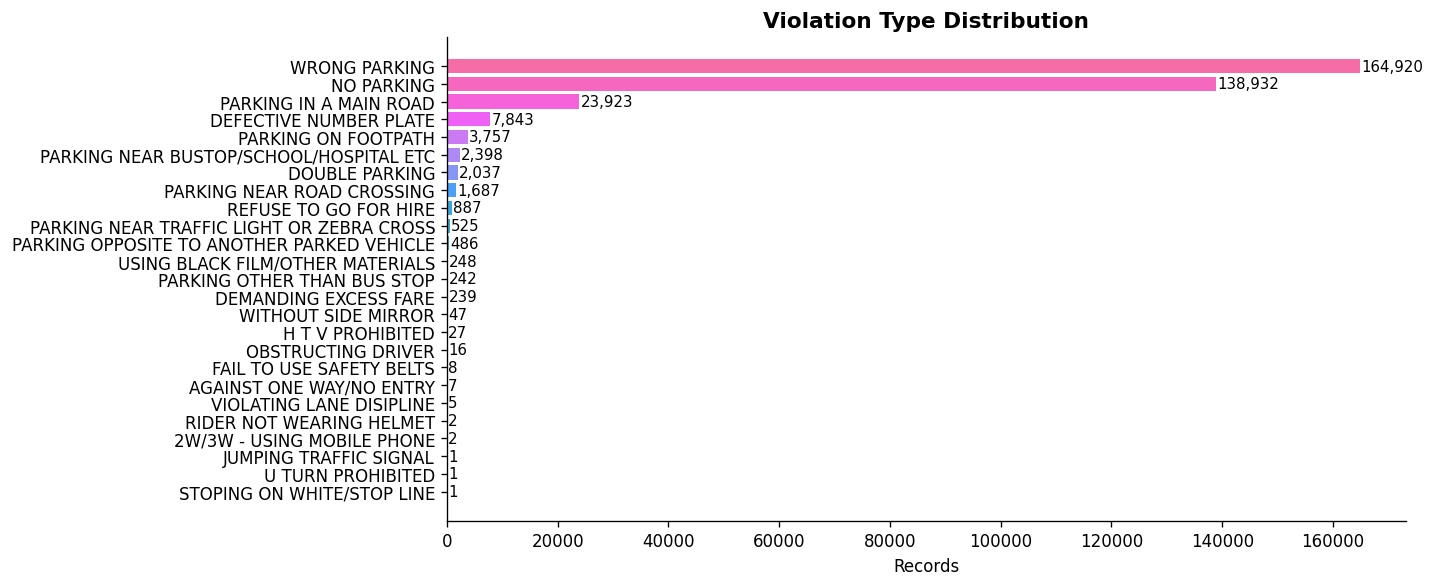

In [15]:
# 5a. Violation type distribution
fig, ax = plt.subplots(figsize=(12,5))
vc = pd.Series(all_violations).value_counts()
bars = ax.barh(vc.index[::-1], vc.values[::-1],
               color=sns.color_palette("husl", len(vc)))
ax.set_xlabel("Records"); ax.set_title("Violation Type Distribution")
for bar,val in zip(bars, vc.values[::-1]):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED/"eda_01_violation_types.png", bbox_inches="tight")
plt.show()


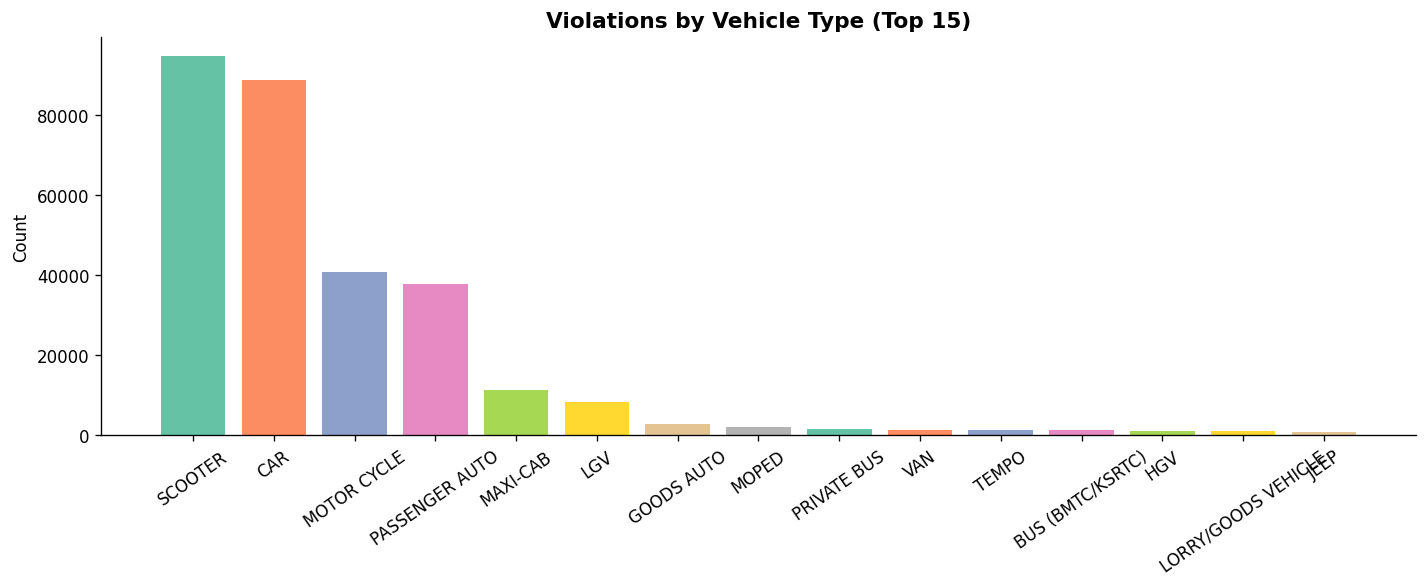

In [16]:
# 5b. Vehicle type
fig, ax = plt.subplots(figsize=(12,5))
vc2 = df["vehicle_type"].value_counts().head(15)
ax.bar(vc2.index, vc2.values, color=sns.color_palette("Set2",15))
ax.set_ylabel("Count"); ax.set_title("Violations by Vehicle Type (Top 15)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(PROCESSED/"eda_02_vehicle_types.png", bbox_inches="tight"); plt.show()


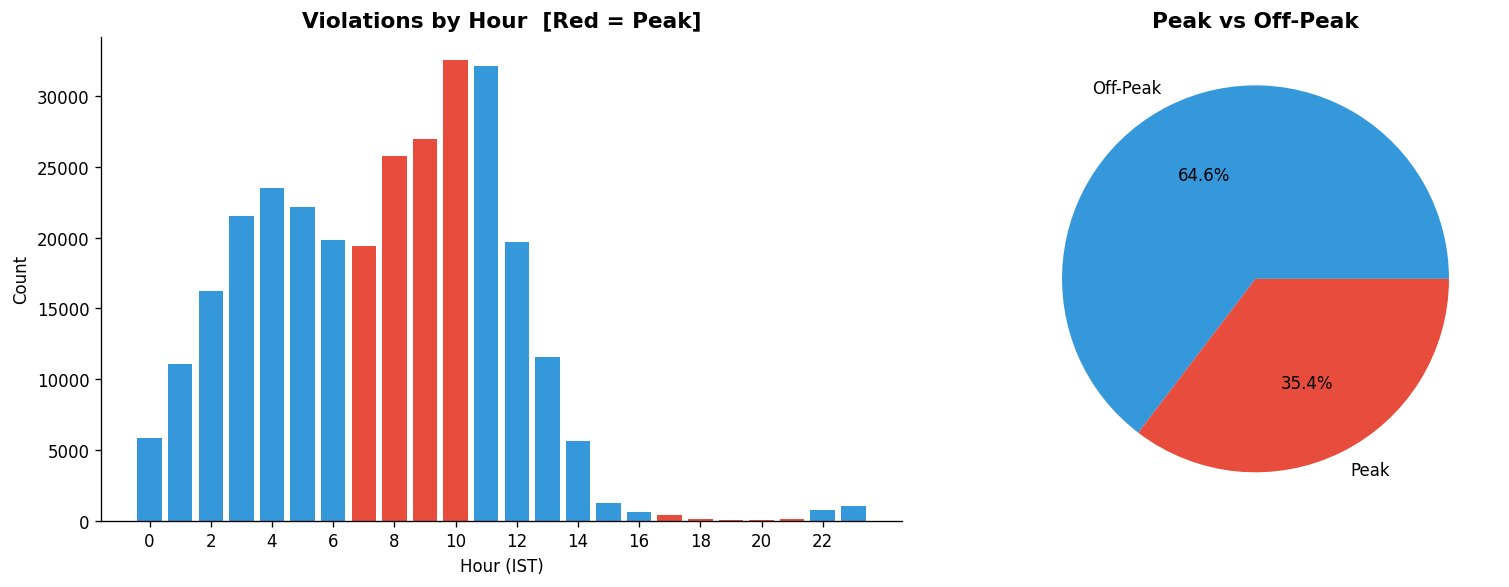

In [17]:
# 5c. Hourly distribution + peak pie
fig, axes = plt.subplots(1,2, figsize=(14,5))
hc = df["hour"].value_counts().sort_index()
axes[0].bar(hc.index, hc.values,
    color=["#e74c3c" if h in list(range(7,11))+list(range(17,22)) else "#3498db"
           for h in hc.index])
axes[0].set_xlabel("Hour (IST)"); axes[0].set_ylabel("Count")
axes[0].set_title("Violations by Hour  [Red = Peak]"); axes[0].set_xticks(range(0,24,2))
pc = df["is_peak_hour"].value_counts()
axes[1].pie(pc.values, labels=["Off-Peak","Peak"],
            colors=["#3498db","#e74c3c"], autopct="%1.1f%%")
axes[1].set_title("Peak vs Off-Peak")
plt.tight_layout()
plt.savefig(PROCESSED/"eda_03_hourly.png", bbox_inches="tight"); plt.show()


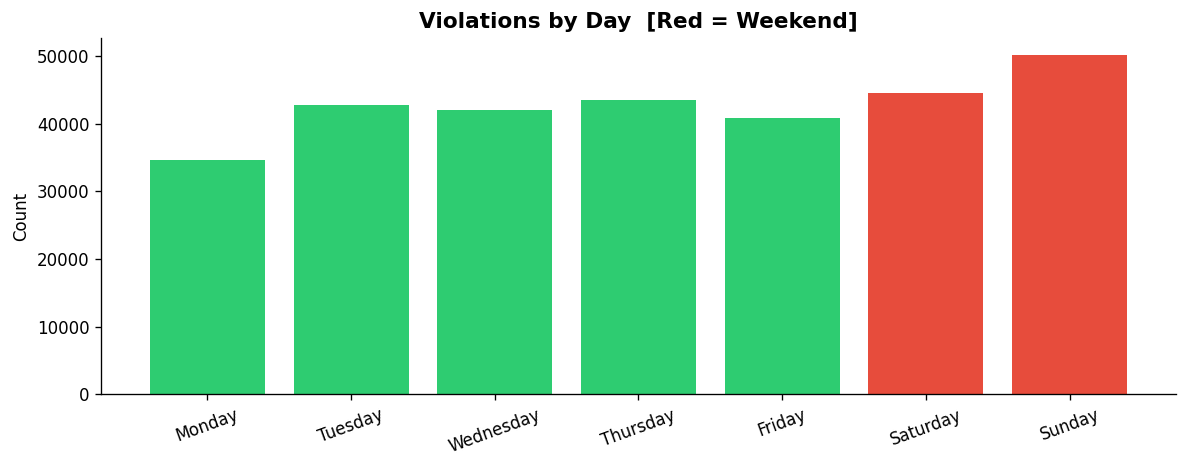

In [18]:
# 5d. Day-of-week
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dc = df["day_name"].value_counts().reindex(day_order)
fig, ax = plt.subplots(figsize=(10,4))
ax.bar(day_order, dc.values,
       color=["#e74c3c" if d in ["Saturday","Sunday"] else "#2ecc71" for d in day_order])
ax.set_ylabel("Count"); ax.set_title("Violations by Day  [Red = Weekend]")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(PROCESSED/"eda_04_dayofweek.png", bbox_inches="tight"); plt.show()


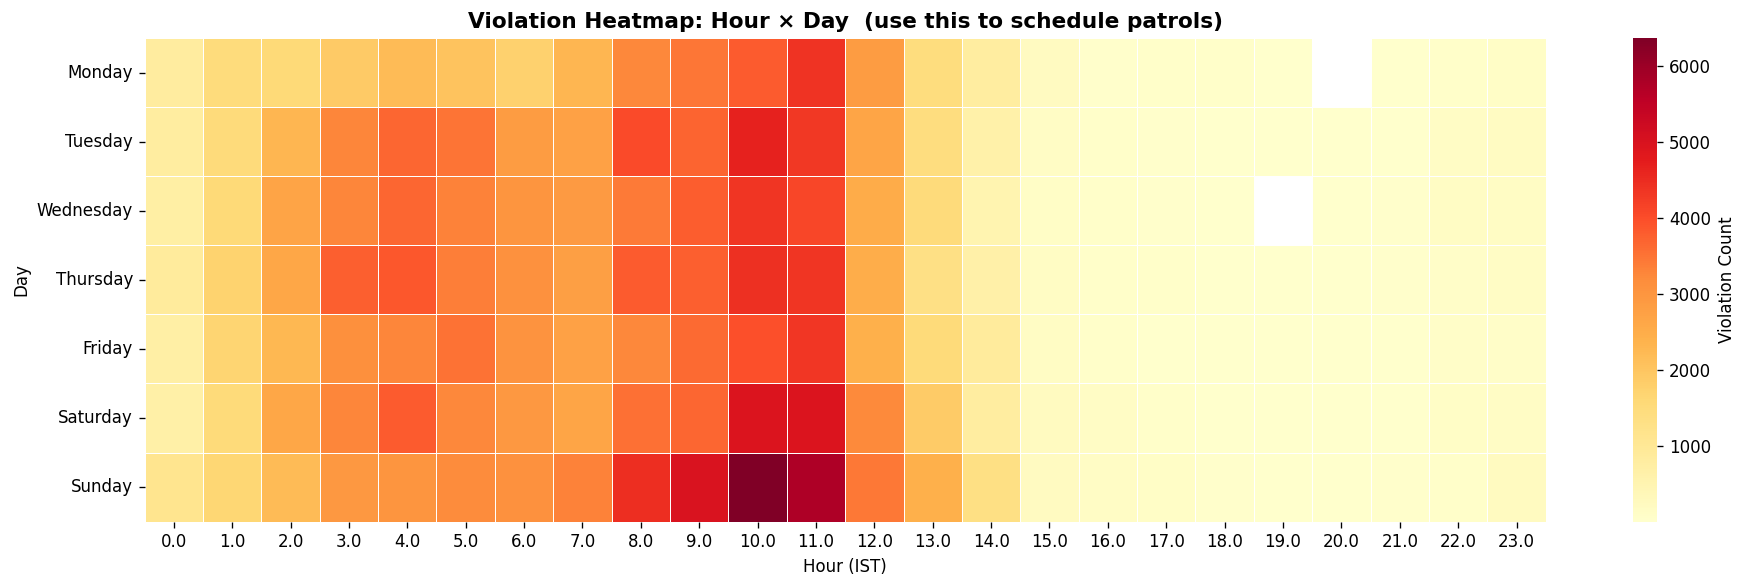

In [19]:
# 5e. Hour x Day heatmap  (most useful single chart)
pivot = df.pivot_table(index="day_name", columns="hour",
                       values="id", aggfunc="count").reindex(day_order)
fig, ax = plt.subplots(figsize=(16,5))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label":"Violation Count"})
ax.set_title("Violation Heatmap: Hour × Day  (use this to schedule patrols)")
ax.set_xlabel("Hour (IST)"); ax.set_ylabel("Day")
plt.tight_layout()
plt.savefig(PROCESSED/"eda_05_hour_day_heatmap.png", bbox_inches="tight"); plt.show()


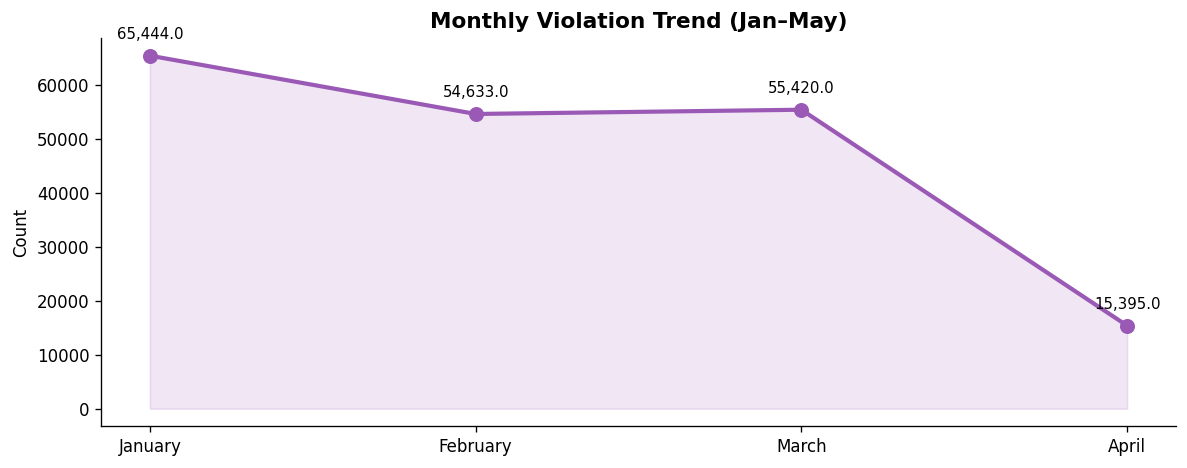

In [20]:
# 5f. Monthly trend
month_order = ["January","February","March","April","May"]
mc = df["month_name"].value_counts().reindex(month_order).dropna()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(mc.index, mc.values, marker="o", lw=2.5, color="#9b59b6", ms=8)
ax.fill_between(mc.index, mc.values, alpha=0.15, color="#9b59b6")
ax.set_ylabel("Count"); ax.set_title("Monthly Violation Trend (Jan–May)")
for x,y in zip(mc.index, mc.values):
    ax.annotate(f"{y:,}", (x,y), textcoords="offset points", xytext=(0,10),
                ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(PROCESSED/"eda_06_monthly.png", bbox_inches="tight"); plt.show()


In [2]:
df["police_station"].value_counts()

NameError: name 'df' is not defined

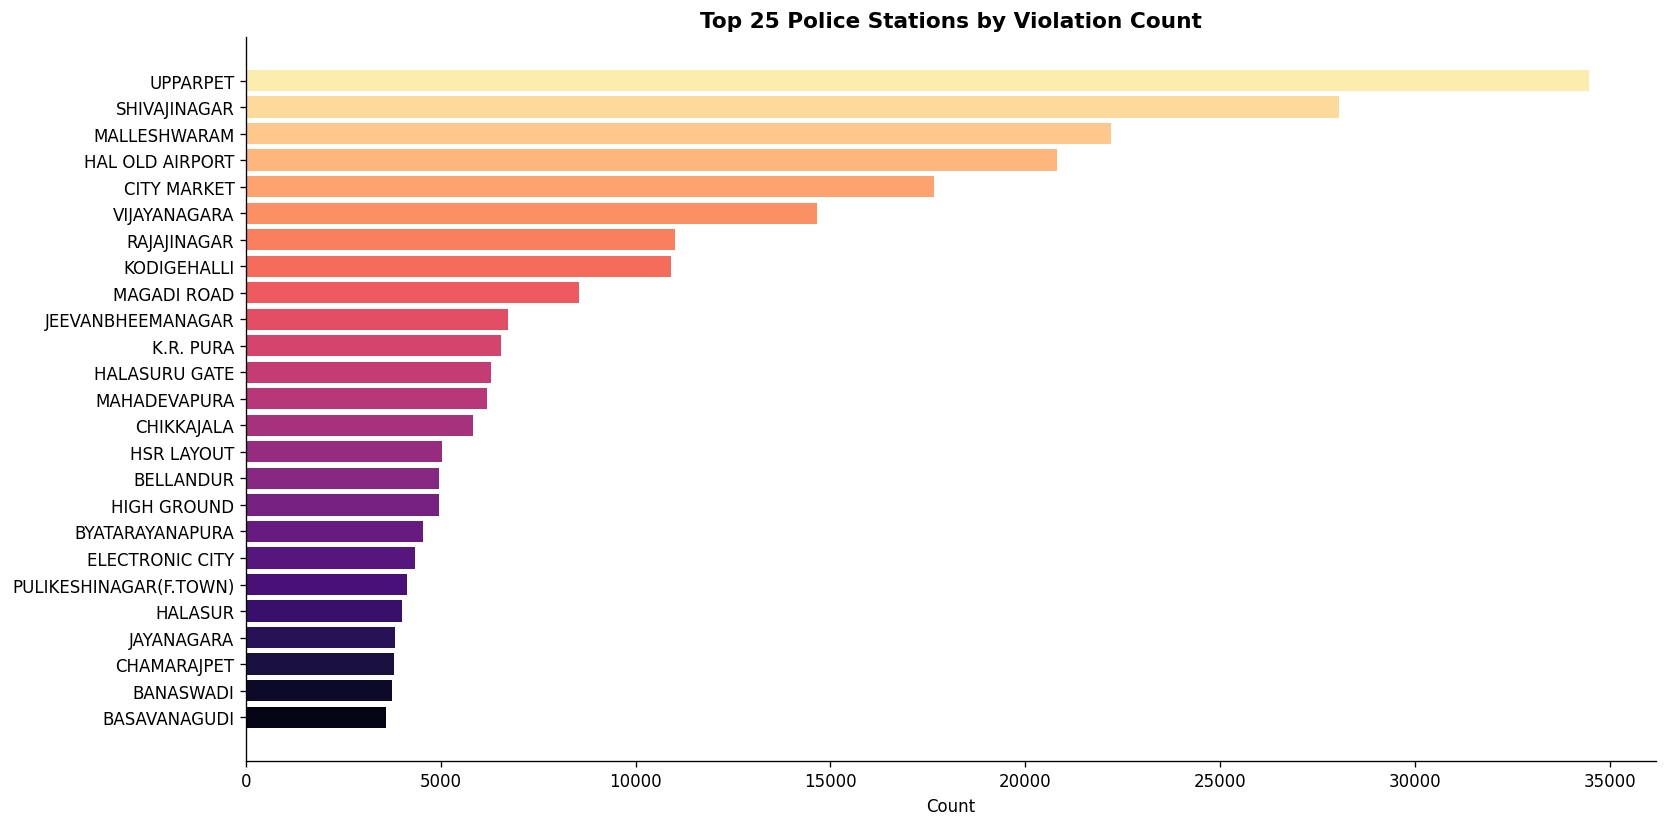

In [21]:
# 5g. Top police stations
fig, ax = plt.subplots(figsize=(14,7))
sc = df["police_station"].value_counts().head(25)
ax.barh(sc.index[::-1], sc.values[::-1], color=sns.color_palette("magma",25))
ax.set_xlabel("Count"); ax.set_title("Top 25 Police Stations by Violation Count")
plt.tight_layout()
plt.savefig(PROCESSED/"eda_07_stations.png", bbox_inches="tight"); plt.show()


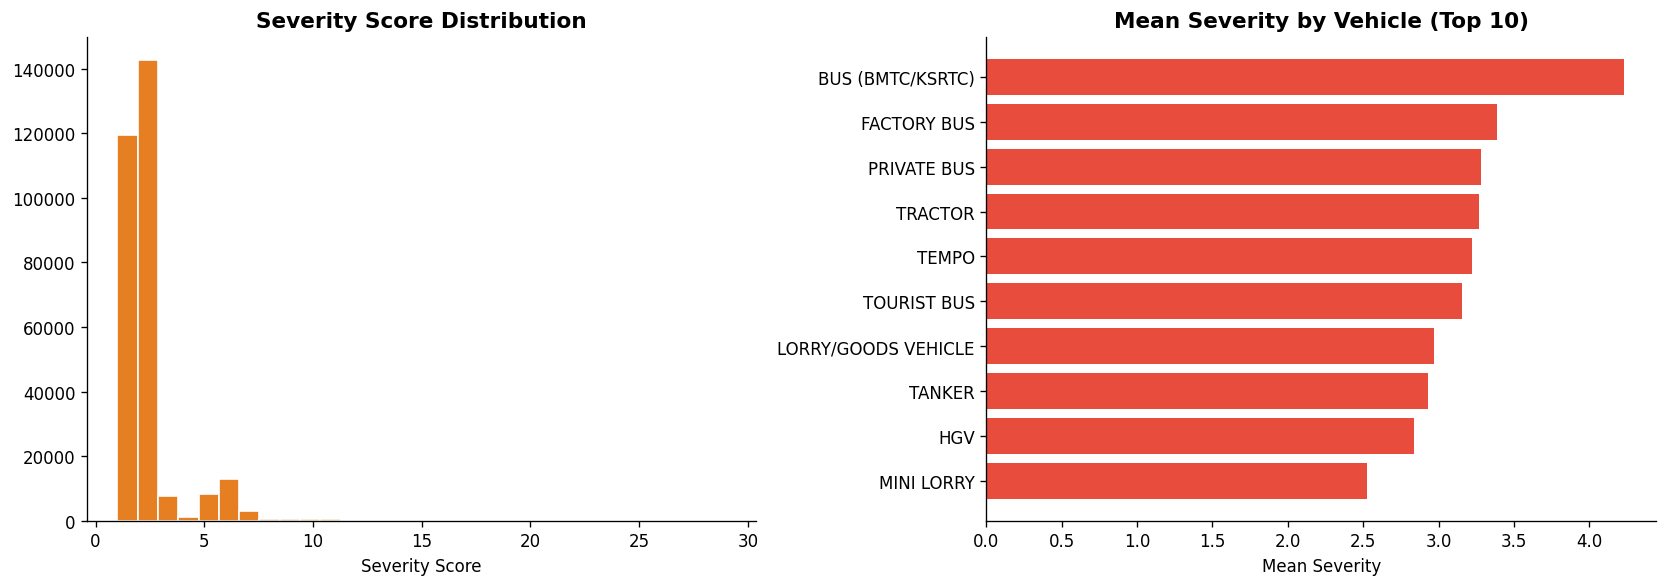

In [22]:
# 5h. Severity distribution + by vehicle
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].hist(df["severity_score"], bins=30, color="#e67e22", edgecolor="white")
axes[0].set_xlabel("Severity Score"); axes[0].set_title("Severity Score Distribution")
sv = df.groupby("vehicle_type")["severity_score"].mean().sort_values(ascending=False).head(10)
axes[1].barh(sv.index[::-1], sv.values[::-1], color="#e74c3c")
axes[1].set_xlabel("Mean Severity"); axes[1].set_title("Mean Severity by Vehicle (Top 10)")
plt.tight_layout()
plt.savefig(PROCESSED/"eda_08_severity.png", bbox_inches="tight"); plt.show()


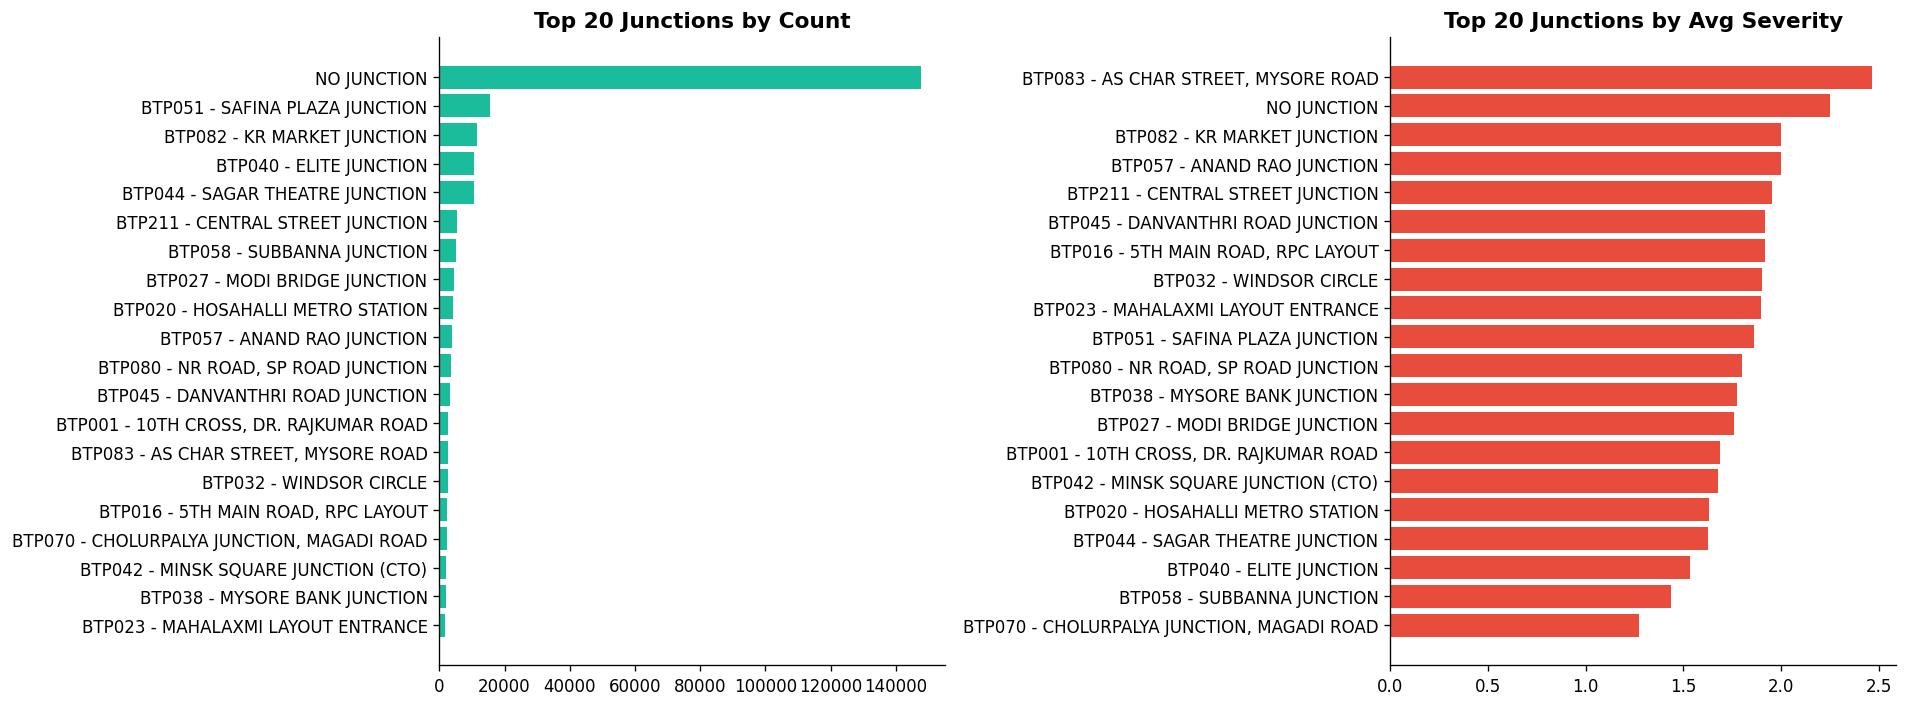

                                   count   avg_sev
junction_name                                     
NO JUNCTION                       147712  2.249858
BTP051 - SAFINA PLAZA JUNCTION     15449  1.861803
BTP082 - KR MARKET JUNCTION        11538  2.002340
BTP040 - ELITE JUNCTION            10718  1.531816
BTP044 - SAGAR THEATRE JUNCTION    10549  1.626410
BTP211 - CENTRAL STREET JUNCTION    5388  1.955085
BTP058 - SUBBANNA JUNCTION          5189  1.438813
BTP027 - MODI BRIDGE JUNCTION       4584  1.758072
BTP020 - HOSAHALLI METRO STATION    4101  1.629115
BTP057 - ANAND RAO JUNCTION         3935  2.000762


In [23]:
# 5i. Top junctions
jdf = (df[df["junction_name"].notna()]
       .groupby("junction_name")
       .agg(count=("id","count"), avg_sev=("severity_score","mean"))
       .sort_values("count", ascending=False).head(20))
fig, axes = plt.subplots(1,2, figsize=(16,6))
axes[0].barh(jdf.index[::-1], jdf["count"][::-1], color="#1abc9c")
axes[0].set_title("Top 20 Junctions by Count")
axes[1].barh(jdf.sort_values("avg_sev",ascending=False).index[::-1],
             jdf.sort_values("avg_sev",ascending=False)["avg_sev"][::-1], color="#e74c3c")
axes[1].set_title("Top 20 Junctions by Avg Severity")
plt.tight_layout()
plt.savefig(PROCESSED/"eda_09_junctions.png", bbox_inches="tight"); plt.show()
print(jdf.head(10))


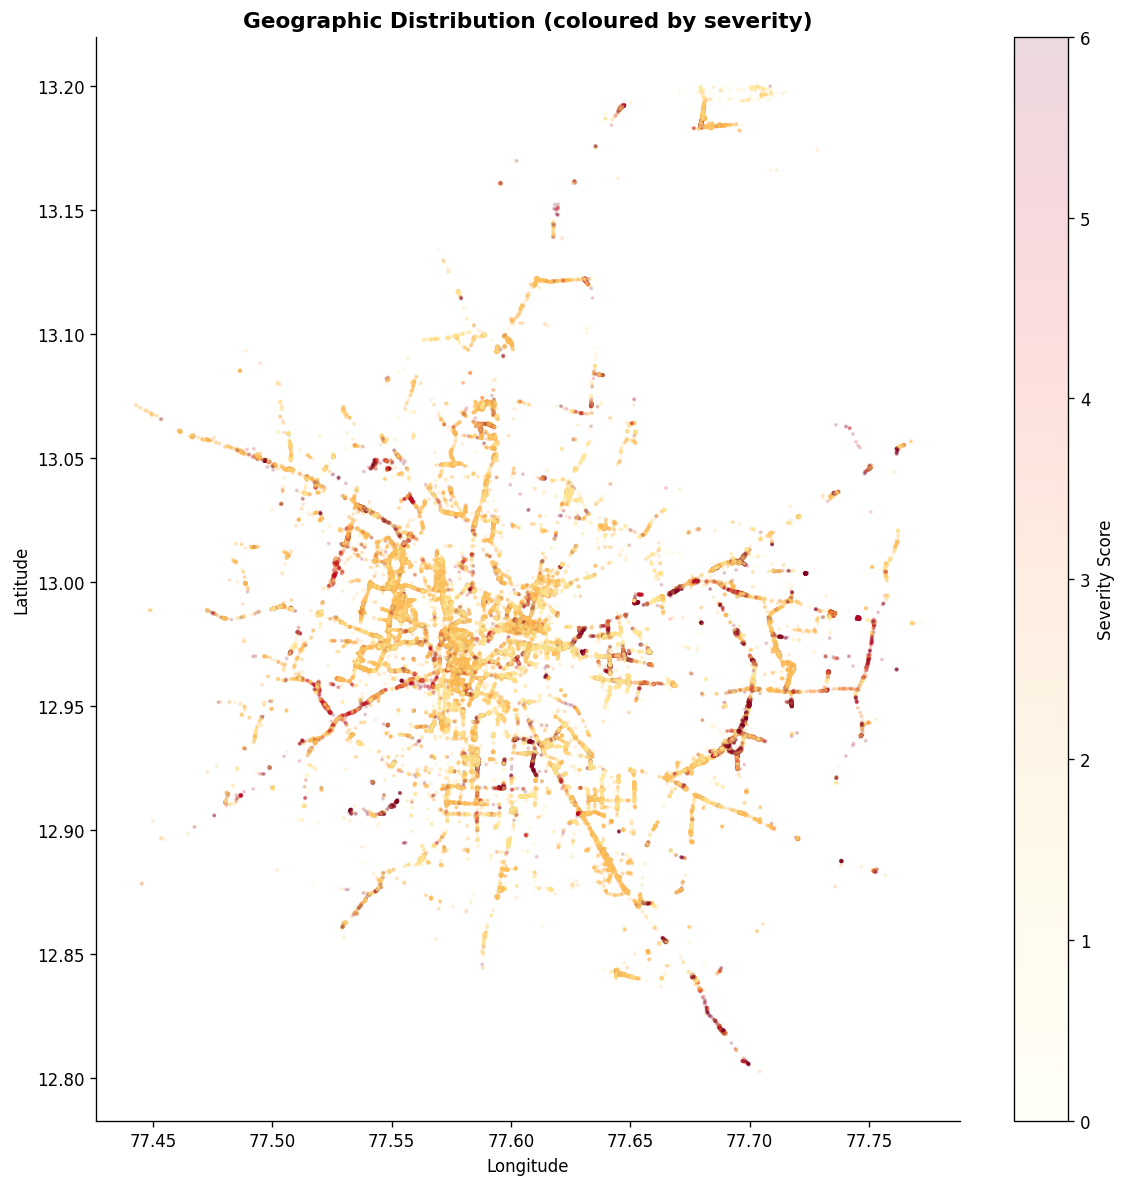

In [24]:
# 5j. Geographic scatter (fast matplotlib version)
fig, ax = plt.subplots(figsize=(10,10))
sc = ax.scatter(df["longitude"], df["latitude"],
                c=df["severity_score"], cmap="YlOrRd",
                alpha=0.15, s=2,
                vmin=0, vmax=df["severity_score"].quantile(0.95))
plt.colorbar(sc, ax=ax, label="Severity Score")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Geographic Distribution (coloured by severity)")
plt.tight_layout()
plt.savefig(PROCESSED/"eda_10_geo.png", dpi=150, bbox_inches="tight"); plt.show()


In [27]:
# 5k. Interactive Folium heatmap (10k sample for speed)
from folium.plugins import HeatMap
sample = df.sample(min(10_000, len(df)), random_state=42)
heat_data = list(zip(sample["latitude"], sample["longitude"],
                     sample["severity_score"].fillna(1)))
m = folium.Map(location=[12.97,77.59], zoom_start=12, tiles="CartoDB dark_matter")
HeatMap(heat_data, radius=10, blur=12, max_zoom=14,
        gradient={"0.2":"blue","0.5":"lime","0.8":"orange","1.0":"red"}).add_to(m)
out_html = str(PROCESSED/"violation_heatmap_day1.html")
m.save(out_html)
print(f"✅ Interactive heatmap saved → {out_html}")
m


✅ Interactive heatmap saved → D:\Coding Stuff\grid2\data\processed\violation_heatmap_day1.html


In [29]:
# 5l. EDA Summary
print("="*65)
print("EDA SUMMARY")
print("="*65)
print(f"  Total clean records     : {len(df):,}")
# Added .dropna() to safely calculate min/max dates
print(f"  Date range              : {df['date'].dropna().min()}  →  {df['date'].dropna().max()}")
print(f"  Unique vehicle types    : {df['vehicle_type'].nunique()}")
print(f"  Unique police stations  : {df['police_station'].nunique()}")
print(f"  Near named junction     : {df['near_junction'].sum():,}  ({df['near_junction'].mean()*100:.1f}%)")
print(f"  Peak-hour records       : {df['is_peak_hour'].sum():,}  ({df['is_peak_hour'].mean()*100:.1f}%)")
print(f"  Mean severity score     : {df['severity_score'].mean():.2f}")
print(f"  Mean impact score       : {df['impact_score'].mean():.2f}")
print(f"  Sent to SCITA           : {df['sent_to_scita'].mean()*100:.1f}%")
print(f"  Approved records        : {df['is_approved'].mean()*100:.1f}%")
print(f"  Busiest hour            : {df.groupby('hour')['id'].count().idxmax()}:00 IST")
print(f"  Worst day               : {df.groupby('day_name')['id'].count().idxmax()}")
print(f"  Top station             : {df['police_station'].value_counts().index[0]}")
print("="*65)

EDA SUMMARY
  Total clean records     : 298,282
  Date range              : 2023-11-10  →  2024-04-08
  Unique vehicle types    : 22
  Unique police stations  : 54
  Near named junction     : 150,565  (50.5%)
  Peak-hour records       : 105,485  (35.4%)
  Mean severity score     : 2.03
  Mean impact score       : 13.19
  Sent to SCITA           : 85.7%
  Approved records        : 38.7%
  Busiest hour            : 10.0:00 IST
  Worst day               : Sunday
  Top station             : UPPARPET


## 6. Save Clean Data

In [30]:
# 6. Save Clean Data
KEEP = [
    "id","latitude","longitude","location",
    "vehicle_number","vehicle_type","violation_list","offence_code_list","num_violations",
    "created_ist","hour","day_of_week","day_name","month","month_name","week","date",
    "is_peak_hour","is_morning_peak","is_evening_peak","is_weekend","time_bucket",
    "severity_score","vehicle_weight","road_rank","near_junction","impact_score",
    "junction_name","police_station","center_code",
    "sent_to_scita","is_approved","is_rejected",
]
df_clean = df[[c for c in KEEP if c in df.columns]].copy()

out_path = PROCESSED / "violations_clean_day1.parquet"
df_clean.to_parquet(out_path, index=False)
size_mb = out_path.stat().st_size / 1e6
print(f"✅ Saved {len(df_clean):,} rows × {df_clean.shape[1]} cols")
print(f"   → {out_path}  ({size_mb:.1f} MB)")
print("\nDAY 1 COMPLETE — run day2_hotspot_model.ipynb next.")

✅ Saved 298,282 rows × 33 cols
   → D:\Coding Stuff\grid2\data\processed\violations_clean_day1.parquet  (13.9 MB)

DAY 1 COMPLETE — run day2_hotspot_model.ipynb next.
